In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
housing=fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

In [17]:
X=df.drop('MedHouseVal',axis=1)
Y=df['MedHouseVal']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
model = LinearRegression(fit_intercept=True,positive=True)
model.fit(X_train_scaled, Y_train)
y_pred = model.predict(X_test_scaled)

In [36]:
print("MAE:", mean_absolute_error(Y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred)))
print("R2 Score:", r2_score(Y_test, y_pred))


MAE: 0.604625230935653
RMSE: 0.8138768752843683
R2 Score: 0.49451233994760124


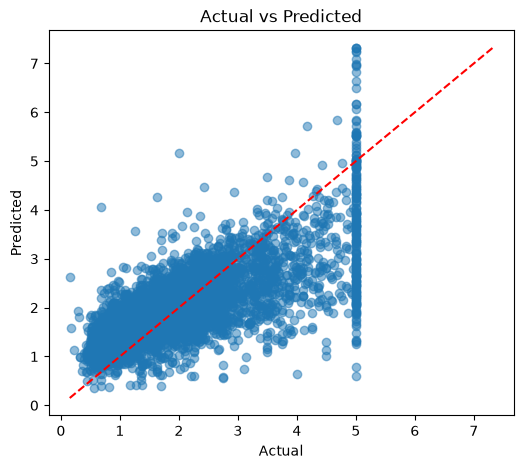

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(Y_test, y_pred, alpha=0.5)
lims = [min(Y_test.min(), y_pred.min()), max(Y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); 
plt.ylabel('Predicted'); 
plt.title('Actual vs Predicted')
plt.show()